In [8]:
# --- User Configuration ---
# Specify the base directory where your organized video data is located.
# This directory should contain 'train', 'val', and 'test' subdirectories,
# each with 'real_videos' and 'fake_videos' folders containing .mp4 files.

#data_path = '/content/drive/MyDrive/DeepfakeData/CompleteData/organized'

#for jojo's run
data_path = '/content/drive/MyDrive/DL_project_finetuned/DeepfakeData/CompleteData/organized'


# Specify the base directory where extracted frames will be saved.
# This directory will mirror the structure of data_path.
#frames_base_dir = '/content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames'

# for jojo's run
frames_base_dir = '/content/drive/MyDrive/DL_project_finetuned/DeepfakeData/CompleteData/organized/frames'

# Specify the base directory where cropped faces will be saved.
# This directory will mirror the structure of data_path.
#crops_base_dir = '/content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops'

#for jojo's run
crops_base_dir = '/content/drive/MyDrive/DL_project_finetuned/DeepfakeData/CompleteData/organized/crops'

# Specify the base directory where training runs and checkpoints will be saved.
#run_base_dir = '/content/drive/MyDrive/DeepfakeData/CompleteData/organized/runs'

# for JoJo's run
run_base_dir = '/content/drive/MyDrive/DL_project_finetuned/DeepfakeData/CompleteData/organized/runs'

# --- End User Configuration ---

In [ ]:
import os

destination_base = '/content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames'
subdirectories = [
    'train/real_videos',
    'train/fake_videos',
    'val/real_videos',
    'val/fake_videos',
    'test/real_videos',
    'test/fake_videos'
]

for subdir in subdirectories:
    full_path = os.path.join(destination_base, subdir)
    os.makedirs(full_path, exist_ok=True)

print("Directories created successfully.")

Directories created successfully.


In [ ]:
import os

video_files = []
main_subdirs = ['train', 'val', 'test']
inner_subdirs = ['real_videos', 'fake_videos']

for main_subdir in main_subdirs:
    main_subdir_path = os.path.join(data_path, main_subdir)
    if os.path.isdir(main_subdir_path):
        for inner_subdir in inner_subdirs:
            inner_subdir_path = os.path.join(main_subdir_path, inner_subdir)
            if os.path.isdir(inner_subdir_path):
                for filename in os.listdir(inner_subdir_path):
                    if filename.endswith('.mp4'):
                        video_files.append(os.path.join(inner_subdir_path, filename))

print(f"Found {len(video_files)} video files.")

Found 1408 video files.


In [ ]:
import subprocess
import os

for video_file in video_files:
    relative_path = os.path.relpath(video_file, data_path)
    # The output directory structure will mirror the input structure within frames_base_dir
    output_dir = os.path.join(frames_base_dir, os.path.dirname(relative_path), os.path.splitext(os.path.basename(video_file))[0])

    # Check if the output directory already exists and is not empty
    if os.path.isdir(output_dir) and len(os.listdir(output_dir)) > 0:
        print(f"Frames for {video_file} already seem to be extracted. Skipping.")
        continue # Skip to the next video file

    os.makedirs(output_dir, exist_ok=True)
    output_frame_pattern = os.path.join(output_dir, '%04d.png')

    ffmpeg_command = [
        'ffmpeg',
        '-i', video_file,
        '-vf', 'fps=3',
        output_frame_pattern
    ]

    try:
        # Added capture_output=True and text=True to capture stderr and stdout
        result = subprocess.run(ffmpeg_command, check=True, capture_output=True, text=True)
        print(f"Successfully extracted frames from {video_file}")
        # Optionally print stdout/stderr for debugging
        # print(f"Stdout: {result.stdout}")
        # print(f"Stderr: {result.stderr}")
    except subprocess.CalledProcessError as e:
        print(f"Error extracting frames from {video_file}: {e}")
        print(f"Stderr: {e.stderr}")
    except FileNotFoundError:
        print("Error: ffmpeg command not found. Make sure ffmpeg is installed and in your PATH.")
    except Exception as e:
        print(f"An unexpected error occurred while processing {video_file}: {e}")

Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/wbuajbdcfs.mp4 already seem to be extracted. Skipping.
Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/iorbtaarte.mp4 already seem to be extracted. Skipping.
Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/iksxzpqxzi.mp4 already seem to be extracted. Skipping.
Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/yiykshcbaz.mp4 already seem to be extracted. Skipping.
Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/uazbhwyysx.mp4 already seem to be extracted. Skipping.
Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/cekarydqba.mp4 already seem to be extracted. Skipping.
Frames for /content/drive/MyDrive/DeepfakeData/CompleteData/organized/train/real_videos/fglewmddcn.mp4 already seem to be extracted. Skipping.

In [ ]:
%pip install mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 38.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: opencv-contrib-python
    Found existing installation: opencv-contrib-python 4.12.0.88
    Uninstalling open

In [ ]:
#!/usr/bin/env python3
"""
crop_faces.py — Detect, 1.3x enlarge, and save 299x299 face crops from frame folders.
Useful to prepare ImageFolder datasets for training.

Input frames dir structure:
frames/
  videoA/frame_00001.jpg
  videoA/frame_00002.jpg
  ...
  videoB/frame_00001.jpg
  ...

Usage:
Run the crop_faces_from_video_folder function with appropriate arguments.
"""

import argparse, os
from pathlib import Path
import cv2
import mediapipe as mp

def enlarge_box(x1,y1,x2,y2, scale, W, H):
    cx, cy = (x1+x2)/2.0, (y1+y2)/2.0
    w, h = (x2-x1)*scale, (y2-y1)*scale
    nx1, ny1 = max(0, int(cx - w/2)), max(0, int(cy - h/2))
    nx2, ny2 = min(W-1, int(cx + w/2)), min(H-1, int(cy + h/2))
    return nx1, ny1, nx2, ny2

def detect_largest_face_mediapipe(img, face_detector):
    # Convert the image to RGB as mediapipe requires RGB input
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = face_detector.process(img_rgb)

    if not results.detections:
        return None

    largest_face = None
    largest_area = 0

    for detection in results.detections:
        bbox = detection.location_data.relative_bounding_box
        ih, iw, _ = img.shape
        x, y, w, h = int(bbox.xmin * iw), int(bbox.ymin * ih), int(bbox.width * iw), int(bbox.height * ih)
        area = w * h
        if area > largest_area:
            largest_area = area
            largest_face = (x, y, x+w, y+h)

    return largest_face


def crop_faces_from_video_folder(frames_dir, out_dir, enlarge_scale=1.3, jpeg_quality=95):
    """
    Detect, enlarge, and save face crops from frame folders.

    Args:
        frames_dir (str): Directory with per-video subfolders of frames.
        out_dir (str): Where to write 299x299 crops.
        enlarge_scale (float, optional): Scale to enlarge the face bounding box. Defaults to 1.3.
        jpeg_quality (int, optional): JPEG quality for saved images. Defaults to 95.
    """
    mp_face_detection = mp.solutions.face_detection
    mp_drawing = mp.solutions.drawing_utils

    frames_root = Path(frames_dir)
    out_root = Path(out_dir)
    out_root.mkdir(parents=True, exist_ok=True)

    videos = sorted([p for p in frames_root.iterdir() if p.is_dir()])
    count = 0

    # Initialize Mediapipe Face Detection
    with mp_face_detection.FaceDetection(
        model_selection=1, min_detection_confidence=0.5) as face_detector:

        for vdir in videos:
            # Change glob pattern to look for .png files
            for fp in sorted(vdir.glob("*.png")):
                out_fp = out_root / f"{vdir.name}_{fp.stem}.jpg" # Save as .jpg as requested

                # Check if cropped file already exists
                if out_fp.exists():
                    # print(f"Crop for {fp} already exists. Skipping.") # Optional: uncomment for verbose skipping
                    continue

                img = cv2.imread(str(fp))
                if img is None:
                    continue
                H, W = img.shape[:2]
                box = detect_largest_face_mediapipe(img, face_detector)
                if box is None:
                    continue
                x1,y1,x2,y2 = box
                x1,y1,x2,y2 = enlarge_box(x1,y1,x2,y2, enlarge_scale, W, H)
                crop = img[y1:y2, x1:x2]
                crop = cv2.resize(crop, (299,299), interpolation=cv2.INTER_AREA)

                cv2.imwrite(str(out_fp), crop, [int(cv2.IMWRITE_JPEG_QUALITY), jpeg_quality])
                count += 1

    print(f"Saved {count} new crops to {out_root}")

# Example usage (you can call this function in a separate cell):
# frames_dir = '/content/drive/MyDrive/DeepfakeData/SampleData/frames' # Replace with your frames directory
# out_dir = '/content/drive/MyDrive/DeepfakeData/SampleData/crops/train/real' # Replace with your desired output directory
# crop_faces_from_video_folder(frames_dir, out_dir)

In [ ]:
import os

subdirectories = [
    'train/real_videos',
    'train/fake_videos',
    'val/real_videos',
    'val/fake_videos',
    'test/real_videos',
    'test/fake_videos'
]

for subdir in subdirectories:
    frames_subdir = os.path.join(frames_base_dir, subdir)
    print(f"Checking directory: {frames_subdir}")
    if os.path.isdir(frames_subdir):
        print("Directory exists.")
        # Check for files within the directory (limit to first few for brevity)
        files_in_dir = os.listdir(frames_subdir)
        if files_in_dir:
            print(f"Found {len(files_in_dir)} items in directory. First 5: {files_in_dir[:5]}")
            # Further check if any expected image files exist within the subdirectories (video folders)
            video_subdirs = [d for d in os.listdir(frames_subdir) if os.path.isdir(os.path.join(frames_subdir, d))]
            if video_subdirs:
                print(f"Found {len(video_subdirs)} video subdirectories. Checking the first one...")
                first_video_subdir = video_subdirs[0]
                first_video_subdir_path = os.path.join(frames_subdir, first_video_subdir)
                frames_in_video_subdir = [f for f in os.listdir(first_video_subdir_path) if f.endswith('.jpg') or f.endswith('.png')]
                if frames_in_video_subdir:
                    print(f"Found {len(frames_in_video_subdir)} image files in {first_video_subdir}. First 5: {frames_in_video_subdir[:5]}")
                else:
                    print(f"No image files found in {first_video_subdir}.")
            else:
                print("No video subdirectories found within this directory.")
        else:
            print("Directory is empty.")
    else:
        print("Directory does not exist.")
    print("-" * 30)

Checking directory: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames/train/real_videos
Directory exists.
Found 142 items in directory. First 5: ['wbuajbdcfs', 'iorbtaarte', 'iksxzpqxzi', 'yiykshcbaz', 'uazbhwyysx']
Found 142 video subdirectories. Checking the first one...
Found 30 image files in wbuajbdcfs. First 5: ['0001.png', '0002.png', '0003.png', '0004.png', '0005.png']
------------------------------
Checking directory: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames/train/fake_videos
Directory exists.
Found 998 items in directory. First 5: ['owxbbpjpch', 'scpglaliyh', 'inzrlbgtul', 'sphirandia', 'ztwlbdwyni']
Found 998 video subdirectories. Checking the first one...
Found 30 image files in owxbbpjpch. First 5: ['0001.png', '0002.png', '0003.png', '0004.png', '0005.png']
------------------------------
Checking directory: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames/val/real_videos
Directory exists.
Found 9 items in directory

In [ ]:
import os

# Define the base directories
# Using the variables defined at the top of the notebook
# Define the subdirectories for frames and crops
subdirectories = [
    'train/real_videos',
    'train/fake_videos',
    'val/real_videos',
    'val/fake_videos',
    'test/real_videos',
    'test/fake_videos'
]

# Process each subdirectory
for subdir in subdirectories:
    frames_subdir = os.path.join(frames_base_dir, subdir)
    crops_subdir = os.path.join(crops_base_dir, subdir)

    # Ensure the output directory exists
    os.makedirs(crops_subdir, exist_ok=True)

    print(f"Processing frames from: {frames_subdir}")
    print(f"Saving crops to: {crops_subdir}")

    # Call the crop_faces_from_video_folder function
    crop_faces_from_video_folder(frames_subdir, crops_subdir)
    print("-" * 30)

print("Face cropping process completed for all subdirectories.")

Processing frames from: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames/train/real_videos
Saving crops to: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/train/real_videos
Saved 0 new crops to /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/train/real_videos
------------------------------
Processing frames from: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames/train/fake_videos
Saving crops to: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/train/fake_videos
Saved 0 new crops to /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/train/fake_videos
------------------------------
Processing frames from: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/frames/val/real_videos
Saving crops to: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/val/real_videos
Saved 0 new crops to /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/val/real_videos
--------

In [ ]:
import os

subdirectories = [
    'train/real_videos',
    'train/fake_videos',
    'val/real_videos',
    'val/fake_videos',
    'test/real_videos',
    'test/fake_videos'
]

print("Checking if crop directories contain data:")

for subdir in subdirectories:
    crops_subdir = os.path.join(crops_base_dir, subdir)
    print(f"Checking directory: {crops_subdir}")
    if os.path.isdir(crops_subdir):
        files_in_dir = os.listdir(crops_subdir)
        if files_in_dir:
            print(f"Directory exists and contains {len(files_in_dir)} files. First 5: {files_in_dir[:5]}")
        else:
            print("Directory exists but is empty.")
    else:
        print("Directory does not exist.")
    print("-" * 30)

Checking if crop directories contain data:
Checking directory: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/train/real_videos
Directory exists and contains 4175 files. First 5: ['ucthmsajay_0017.jpg', 'ucthmsajay_0018.jpg', 'ucthmsajay_0019.jpg', 'ucthmsajay_0020.jpg', 'ucthmsajay_0021.jpg']
------------------------------
Checking directory: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/train/fake_videos
Directory exists and contains 29804 files. First 5: ['zbvlctwcqr_0016.jpg', 'zbvlctwcqr_0017.jpg', 'zbvlctwcqr_0018.jpg', 'zbvlctwcqr_0019.jpg', 'zbvlctwcqr_0020.jpg']
------------------------------
Checking directory: /content/drive/MyDrive/DeepfakeData/CompleteData/organized/crops/val/real_videos
Directory exists and contains 267 files. First 5: ['doniqevxeg_0001.jpg', 'doniqevxeg_0002.jpg', 'doniqevxeg_0003.jpg', 'doniqevxeg_0004.jpg', 'doniqevxeg_0005.jpg']
------------------------------
Checking directory: /content/drive/MyDrive/DeepfakeData/

In [ ]:
%pip install timm==0.6.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.1/549.1 kB 12.0 MB/s eta 0:00:00
  Attempting uninstall: timm
    Found existing installation: timm 1.0.20
    Uninstalling timm-1.0.20:
      Successfully uninstalled timm-1.0.20


In [ ]:
!pip install torch_xla

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 MB 3.4 MB/s eta 0:00:00


In [ ]:
!pip install --upgrade torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.

In [11]:
#!/usr/bin/env python3
"""
train_xception.py — Fine-tune XceptionNet (via timm) on face crops (real/fake)
Dataset layout (ImageFolder style):
crops/
  train/real/*.jpg
  train/fake/*.jpg
  val/real/*.jpg
  val/fake/*.jpg

Usage:
Run the train_model function with appropriate arguments.
"""

import argparse, os, random, time, math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

try:
    import timm
except Exception as e:
    raise SystemExit("Please install timm: pip install timm==1.*") from e

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [ ]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def build_loaders(data_dir, img_size=299, batch_size=64, num_workers=8):
    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.9, 1.0)),
        transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
        transforms.ColorJitter(0.1,0.1,0.1,0.05),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    val_tf = transforms.Compose([
        transforms.Resize(img_size),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    train_ds = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_tf)
    val_ds   = datasets.ImageFolder(os.path.join(data_dir, "val"),   transform=val_tf)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, train_ds.classes

In [9]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

def evaluate_frame_level(model, loader, device):
    model.eval()
    all_logits, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            all_logits.append(logits.cpu())
            all_targets.append(y)
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0).numpy()
    probs = torch.softmax(logits, dim=1).numpy()[:,1]
    preds = (probs >= 0.5).astype(np.int64)

    metrics = {}
    metrics["acc"] = float(accuracy_score(targets, preds))
    metrics["f1"]  = float(f1_score(targets, preds))
    try:
        metrics["auc"] = float(roc_auc_score(targets, probs))
        metrics["ap_fake"] = float(average_precision_score(targets, probs))
    except Exception:
        metrics["auc"] = float("nan")
        metrics["ap_fake"] = float("nan")

    # Calculate confusion matrix
    cm = confusion_matrix(targets, preds)

    return metrics, cm

In [ ]:
def save_checkpoint(state, is_best, out_dir, name="xception"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt = out_dir / f"{name}_last.pt"
    torch.save(state, ckpt)
    if is_best:
        best = out_dir / f"{name}_best.pt"
        torch.save(state, best)

In [28]:
def train_model(data_dir, out_dir, epochs_head=3, epochs_full=15, batch_size=64, img_size=299, num_workers=8, seed=42, lr_head=3e-4, lr_full=1e-4, weight_decay=1e-4):
    seed_everything(seed)

    # Use CUDA device if available, otherwise CPU
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    train_loader, val_loader, classes = build_loaders(data_dir, img_size, batch_size, num_workers)
    print(f"Classes: {classes} (expect ['fake', 'real'] or similar two classes)")

    # Build model
    model = timm.create_model("xception", pretrained=True, num_classes=2)
    model = model.to(device)

    # Phase 1: freeze backbone, train head
    head_params = []
    for n, p in model.named_parameters():
        if "fc" in n or "classifier" in n:
            head_params.append(p)
            p.requires_grad = True
        else:
            p.requires_grad = False

    opt = torch.optim.AdamW(head_params, lr=lr_head, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()

    best_val = -1.0

    def train_one_epoch(epoch, model, loader, optimizer, criterion, device):
        model.train()
        losses = []
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        return float(np.mean(losses))

    print("==> Phase 1: training the head")
    for epoch in range(1, epochs_head+1):
        tr_loss = train_one_epoch(epoch, model, train_loader, opt, crit, device)
        val_metrics, val_cm = evaluate_frame_level(model, val_loader, device)
        score = val_metrics["acc"]
        is_best = score > best_val
        if is_best: best_val = score
        save_checkpoint({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "val_metrics": val_metrics,
            "args": {
                "data_dir": data_dir, "out_dir": out_dir, "epochs_head": epochs_head,
                "epochs_full": epochs_full, "batch_size": batch_size, "img_size": img_size,
                "num_workers": num_workers, "seed": seed, "lr_head": lr_head,
                "lr_full": lr_full, "weight_decay": weight_decay
            },
        }, is_best, out_dir, name="xception")
        print(f"[Head {epoch}/{epochs_head}] loss={tr_loss:.4f}  val={val_metrics}")
        print("Validation Confusion Matrix:\n", val_cm)

    # Phase 2: unfreeze all, train
    for p in model.parameters():
        p.requires_grad = True
    opt = torch.optim.AdamW(model.parameters(), lr=lr_full, weight_decay=weight_decay)

    print("==> Phase 2: fine-tuning all layers")
    total_epochs = epochs_full
    for epoch in range(1, total_epochs+1):
        tr_loss = train_one_epoch(epoch, model, train_loader, opt, crit, device)
        val_metrics, val_cm = evaluate_frame_level(model, val_loader, device)
        score = val_metrics["acc"]
        is_best = score > best_val
        if is_best: best_val = score
        save_checkpoint({
            "epoch": epochs_head + epoch,
            "model_state": model.state_dict(),
            "val_metrics": val_metrics,
            "args": {
                "data_dir": data_dir, "out_dir": out_dir, "epochs_head": epochs_head,
                "epochs_full": epochs_full, "batch_size": batch_size, "img_size": img_size,
                "num_workers": num_workers, "seed": seed, "lr_head": lr_head,
                "lr_full": lr_full, "weight_decay": weight_decay
            },
        }, is_best, out_dir, name="xception")
        print(f"[FT {epoch}/{total_epochs}] loss={tr_loss:.4f}  val={val_metrics}")
        print("Validation Confusion Matrix:\n", val_cm)

    print("Training complete. Best val acc:", best_val)
# Example usage (you can call this function in a separate cell):
data_dir = crops_base_dir
out_dir = f'{run_base_dir}/xception_dfdc' # Replace with your desired output directory for runs
train_model(data_dir, out_dir, batch_size=32) # Reduced batch size to mitigate OOM

NameError: name 'seed_everything' is not defined

In [12]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
from sklearn.metrics import confusion_matrix # Import confusion_matrix

# Define the path to the best model checkpoint
out_dir = f'{run_base_dir}/xception_dfdc'  # Make sure this matches your training output directory
best_model_path = os.path.join(out_dir, 'xception_best.pt')

# Define the path to the test data
data_dir = crops_base_dir # Make sure this matches your crops directory
test_data_dir = os.path.join(data_dir, 'test')

# Check if the best model checkpoint exists
if not os.path.exists(best_model_path):
    print(f"Error: Best model checkpoint not found at {best_model_path}")
else:
    # Load the best model state
    checkpoint = torch.load(best_model_path)

    # Build the model architecture (needs to match the one used for training)
    import timm
    model = timm.create_model("xception", pretrained=False, num_classes=2) # pretrained=False because we are loading a trained model
    model.load_state_dict(checkpoint['model_state'])

    # Set the model to evaluation mode
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    print(f"Loaded best model from {best_model_path} and set to evaluation mode on {device}.")

    # Define the transformations for the test set (same as validation)
    img_size = 299
    test_tf = transforms.Compose([
        transforms.Resize(img_size),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # Create the test dataset and dataloader
    try:
        test_ds = datasets.ImageFolder(test_data_dir, transform=test_tf)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True) # Use a reasonable batch size
        print(f"Created test dataset with {len(test_ds)} images.")

        # Evaluate the model on the test set and get confusion matrix
        print("Evaluating model on the test set...")
        test_metrics, test_cm = evaluate_frame_level(model, test_loader, device)

        print("\nTest Set Metrics:")
        print(f"  Accuracy: {test_metrics['acc']:.4f}")
        print(f"  F1 Score: {test_metrics['f1']:.4f}")
        print(f"  AUC: {test_metrics['auc']:.4f}")
        print(f"  AP (Fake): {test_metrics['ap_fake']:.4f}")
        print("\nTest Set Confusion Matrix:\n", test_cm)


    except FileNotFoundError:
        print(f"Error: Test data directory not found at {test_data_dir}. Please ensure the path is correct.")
    except Exception as e:
        print(f"An error occurred during test set evaluation: {e}")

Loaded best model from /content/drive/MyDrive/DL_project_finetuned/DeepfakeData/CompleteData/organized/runs/xception_dfdc/xception_best.pt and set to evaluation mode on cuda.
Created test dataset with 4004 images.
Evaluating model on the test set...

Test Set Metrics:
  Accuracy: 0.9795
  F1 Score: 0.8423
  AUC: 0.9492
  AP (Fake): 0.8786

Test Set Confusion Matrix:
 [[3703   31]
 [  51  219]]


In [13]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [15]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
from sklearn.metrics import confusion_matrix # Import confusion_matrix
import timm

# Define the path to the best model checkpoint
out_dir = f'{run_base_dir}/xception_dfdc'  # Make sure this matches your training output directory
best_model_path = os.path.join(out_dir, 'xception_best.pt')

# Define the path to the data
data_dir = crops_base_dir # Make sure this matches your crops directory
train_data_dir = os.path.join(data_dir, 'train')
test_data_dir = os.path.join(data_dir, 'test')

# Check if the best model checkpoint exists
if not os.path.exists(best_model_path):
    print(f"Error: Best model checkpoint not found at {best_model_path}")
else:
    # Load the best model state
    checkpoint = torch.load(best_model_path)

    # Build the model architecture (needs to match the one used for training)
    model = timm.create_model("xception", pretrained=False, num_classes=2) # pretrained=False because we are loading a trained model
    model.load_state_dict(checkpoint['model_state'])

    # Set the model to evaluation mode
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.eval()
    print(f"Loaded best model from {best_model_path} and set to evaluation mode on {device}.")

    # Define the transformations for the datasets
    img_size = 299
    data_tf = transforms.Compose([
        transforms.Resize(img_size),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # Create the train and test datasets and dataloaders
    try:
        train_ds = datasets.ImageFolder(train_data_dir, transform=data_tf)
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
        print(f"Created train dataset with {len(train_ds)} images.")

        test_ds = datasets.ImageFolder(test_data_dir, transform=data_tf)
        test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
        print(f"Created test dataset with {len(test_ds)} images.")

        # Evaluate the model on the train set and get confusion matrix
        print("\nEvaluating model on the training set...")
        train_metrics, train_cm = evaluate_frame_level(model, train_loader, device)

        print("\nTrain Set Confusion Matrix:\n", train_cm)

        # Evaluate the model on the test set and get confusion matrix
        print("\nEvaluating model on the test set...")
        test_metrics, test_cm = evaluate_frame_level(model, test_loader, device)

        print("\nTest Set Confusion Matrix:\n", test_cm)


    except FileNotFoundError:
        print(f"Error: Data directory not found. Please ensure '{train_data_dir}' and '{test_data_dir}' exist.")
    except Exception as e:
        print(f"An error occurred during evaluation: {e}")

Loaded best model from /content/drive/MyDrive/DL_project_finetuned/DeepfakeData/CompleteData/organized/runs/xception_dfdc/xception_best.pt and set to evaluation mode on cuda.
Created train dataset with 33979 images.
Created test dataset with 4004 images.

Evaluating model on the training set...

Train Set Confusion Matrix:
 [[29777    27]
 [   34  4141]]

Evaluating model on the test set...

Test Set Confusion Matrix:
 [[3703   31]
 [  51  219]]


In [17]:
# Assuming train_metrics and test_metrics are available from previous cell execution

if 'train_metrics' in locals() and 'test_metrics' in locals():
    print("--- Overfitting/Underfitting Check ---")
    print("Comparing Training and Testing Metrics:")
    print(f"Accuracy: Train = {train_metrics['acc']:.4f}, Test = {test_metrics['acc']:.4f}")
    print(f"F1 Score: Train = {train_metrics['f1']:.4f}, Test = {test_metrics['f1']:.4f}")
    print(f"AUC:      Train = {train_metrics['auc']:.4f}, Test = {test_metrics['auc']:.4f}")
    print(f"AP (Fake):Train = {train_metrics['ap_fake']:.4f}, Test = {test_metrics['ap_fake']:.4f}")

    # Simple check for overfitting (if train metric is significantly higher than test metric)
    # and underfitting (if both train and test metrics are low)

    accuracy_diff = train_metrics['acc'] - test_metrics['acc']
    f1_diff = train_metrics['f1'] - test_metrics['f1']

    print("\nAnalysis:")
    if accuracy_diff > 0.1 or f1_diff > 0.1: # Thresholds can be adjusted
        print("Potential Overfitting: Training performance is significantly better than testing performance.")
    elif train_metrics['acc'] < 0.7 or test_metrics['acc'] < 0.7: # Thresholds can be adjusted
         print("Potential Underfitting: Both training and testing performance are relatively low.")
    else:
        print("Model performance on training and testing sets is relatively balanced. No strong indication of overfitting or underfitting based on these simple checks.")

else:
    print("Training and testing metrics not found. Please run the evaluation cell first.")

--- Overfitting/Underfitting Check ---
Comparing Training and Testing Metrics:
Accuracy: Train = 0.9982, Test = 0.9795
F1 Score: Train = 0.9927, Test = 0.8423
AUC:      Train = 0.9994, Test = 0.9492
AP (Fake):Train = 0.9987, Test = 0.8786

Analysis:
Potential Overfitting: Training performance is significantly better than testing performance.


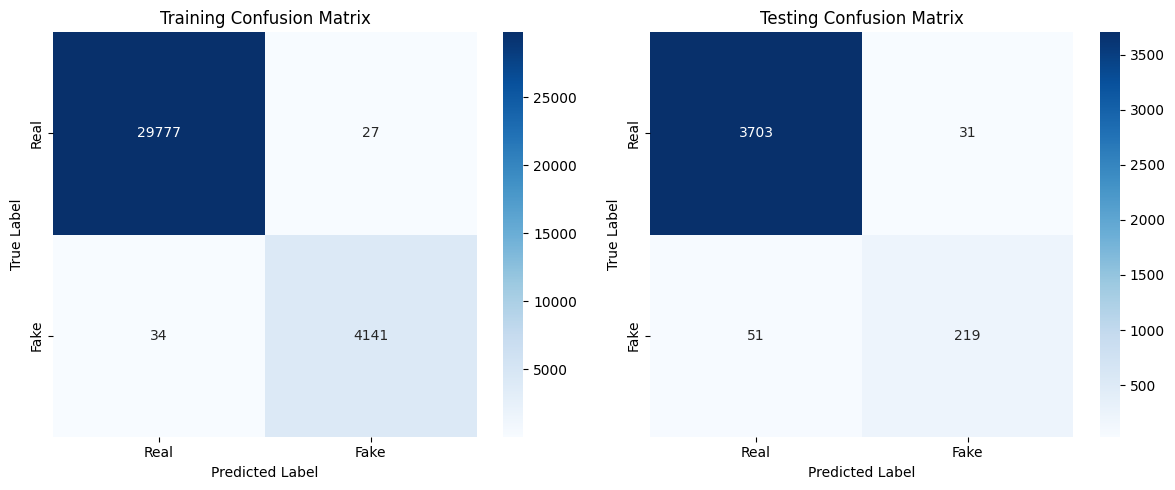

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming train_cm and test_cm are available from previous cell execution

if 'train_cm' in locals() and 'test_cm' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot training confusion matrix
    sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Training Confusion Matrix')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    axes[0].set_xticklabels(['Real', 'Fake'])
    axes[0].set_yticklabels(['Real', 'Fake'])

    # Plot testing confusion matrix
    sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Testing Confusion Matrix')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
    axes[1].set_xticklabels(['Real', 'Fake'])
    axes[1].set_yticklabels(['Real', 'Fake'])

    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrices (train_cm and test_cm) not found. Please run the evaluation cell first.")

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
